# Experiment 2B: SSC — Hidden-Layer Perturbation

## Overview

This notebook implements Experiment 2B from the "Beyond Beyond Rate" project.
We train a 2-hidden-layer SNN on the Spiking Speech Commands (SSC) dataset
with **no perturbation** (f=0), then evaluate it by applying spike-timing
perturbation to the **output of the 1st hidden layer** at test time.

### Key questions
- On SSC-norm (zero rate information in input), does the 1st hidden layer
  output still carry temporal information?
- Does SGD-delay maintain richer internal temporal representations than SGD?
- How does the hidden accuracy-vs-f curve compare to the input perturbation
  curve from the original *Beyond Rate* paper?
- Does the pattern found on SHD hold on this harder 35-class task?

### Dataset variants
| Variant | Description |
|---------|-------------|
| `whole` | Full-rate SSC: all rate and temporal information intact |
| `part`  | Partial SSC: reduced input channels, some rate info removed |
| `norm`  | Normalised SSC: rate information removed, only temporal cues remain |

### Sections
1. Imports and Setup
2. Global Configuration
3. Load SSC Dataset
4. Hidden-Layer Spike Perturbation
5. Dataset and Data Splitting
6. Network Architecture
7. Training Loop
8. Testing with Hidden-Layer Perturbation
9. Visualisation Utilities
10. Run: Train the Model (f=0)
11. Plot Training Curves
12. Hidden-Perturbation Sweep
13. Plot Results
14. Save Results
15. Model Analysis

## 1. Imports and Setup

In [1]:
import os
import json
import random

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here so that switching
between dataset variants or delay/no-delay mode requires editing only
this cell.

In [2]:
# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay)
# =====================================================================
USE_DELAY: bool = False

# =====================================================================
# Dataset variant: "whole", "part", or "norm"
# =====================================================================
DATASET_KEY: str = "norm"

# --- Dataset configurations ---
# whole: 700 input neurons (full SSC)
# part / norm: 285 input neurons (sub-sampled / rate-normalised)
DATASET_CONFIGS = {
    "whole": {"h5_file": "ssc_data/ssc_whole.h5", "input_dim": 700},
    "part":  {"h5_file": "ssc_data/ssc_part.h5",  "input_dim": 285},
    "norm":  {"h5_file": "ssc_data/ssc_norm.h5",  "input_dim": 285},
}

# --- SLAYER neuron and simulation descriptors ---
# tSample=200 matches the original Beyond Rate training pipeline.
# SSC data has T=100; samples are zero-padded to T=200 on load.
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios (applied to the combined h5 dataset) ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE   = (0.6, 0.75)
TEST_RANGE  = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS: int        = 128
NUM_CLASSES: int         = 35   # SSC has 35 spoken-word classes
EPOCHS: int              = 600
BATCH_SIZE: int          = 128
LEARNING_RATE: float     = 0.1
SEED: int                = 42
MAX_DELAY: int           = 64
EARLY_STOP_PATIENCE: int = 300

# --- Hidden-perturbation sweep ---
F_VALUES: list   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS: int = 3
# --- Chunked training (to fit large datasets in RAM) ---
# Training data is split into this many chunks; each chunk is loaded
# into memory one at a time.  Val/test are loaded fully.
# Set to 1 for part/norm (small enough to fit), 3+ for whole.
N_TRAIN_CHUNKS: int = 1

# --- Derived names (do not edit manually) ---
INPUT_DIM: int    = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
H5_FILE: str      = DATASET_CONFIGS[DATASET_KEY]["h5_file"]
DELAY_TAG: str    = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"ssc_{DATASET_KEY}_{DELAY_TAG}"

print(f"Dataset: {DATASET_KEY} | Input dim: {INPUT_DIM}")
print(f"Network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
print(f"Model prefix: {MODEL_PREFIX}")

Dataset: norm | Input dim: 285
Network mode: SGD (no delay)
Model prefix: ssc_norm_nodelay


## 3. Load SSC Dataset

Load the dense spike-train dataset from the local `.h5` file.
Each sample has shape `(num_neurons, T)` with binary spike values.
The raw SSC data has T=100 time steps; samples are zero-padded to
T=200 to match `tSample` in the SLAYER simulation parameters.

In [3]:
def load_split_from_h5(
    h5_path: str,
    indices: np.ndarray,
    target_T: int = 200,
) -> tuple:
    """Load a subset of samples from an HDF5 file into memory.

    Args:
        h5_path: Path to the HDF5 file with keys 'X' and 'Y'.
        indices: Sorted array of sample indices to load.
        target_T: Target time dimension (zero-pad if shorter).

    Returns:
        Tuple (X, Y) as uint8 / int arrays.
    """
    with h5py.File(h5_path, "r") as hf:
        X = np.array(hf["X"][sorted(indices)], dtype=np.uint8)
        Y = np.array(hf["Y"][sorted(indices)]).astype(int).ravel()

    n, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n, n_neurons, target_T), dtype=np.uint8)
        padded[:, :, :T] = X
        X = padded

    return X, Y


def probe_and_load_eval_data(
    h5_path: str,
    target_T: int = 200,
) -> tuple:
    """Probe dataset metadata and load val/test splits into memory.

    Training data is NOT loaded here -- it will be loaded in chunks
    during training to keep memory usage low.

    Args:
        h5_path: Path to the HDF5 dataset file.
        target_T: Target time dimension for zero-padding.

    Returns:
        Tuple of (n_samples, train_indices, val_data, test_data) where
        val_data and test_data are (X, Y) tuples.
    """
    with h5py.File(h5_path, "r") as hf:
        n_samples = hf["X"].shape[0]

    # Compute split indices
    train_idx = np.arange(
        int(n_samples * TRAIN_RANGE[0]), int(n_samples * TRAIN_RANGE[1])
    )
    val_idx = np.arange(
        int(n_samples * VAL_RANGE[0]), int(n_samples * VAL_RANGE[1])
    )
    test_idx = np.arange(
        int(n_samples * TEST_RANGE[0]), int(n_samples * TEST_RANGE[1])
    )

    # Load val and test fully into memory (small enough)
    X_val, Y_val = load_split_from_h5(h5_path, val_idx, target_T)
    X_test, Y_test = load_split_from_h5(h5_path, test_idx, target_T)

    val_mem = X_val.nbytes / (1024 ** 3)
    test_mem = X_test.nbytes / (1024 ** 3)
    print(
        f"Dataset: {n_samples} samples total | "
        f"Train: {len(train_idx)} (chunked, {N_TRAIN_CHUNKS} chunks) | "
        f"Val: {len(val_idx)} ({val_mem:.1f} GiB) | "
        f"Test: {len(test_idx)} ({test_mem:.1f} GiB)"
    )
    return n_samples, train_idx, (X_val, Y_val), (X_test, Y_test)


n_samples, train_indices, val_data, test_data = probe_and_load_eval_data(
    H5_FILE, target_T=SIM_PARAMS["tSample"]
)

Dataset: 40390 samples total | Train: 24234 (chunked, 1 chunks) | Val: 6058 (0.3 GiB) | Test: 6059 (0.3 GiB)


## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This preserves the **spike
count per neuron** while destroying **spike-timing** information in proportion
to `f`.

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes.

    For every neuron, *f* of its spikes are removed from their original
    positions and placed at uniformly random empty time bins. The total
    spike count per neuron is preserved.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = no change, 1 = full shuffle).
        max_attempts: Max tries to find an empty time bin per spike.

    Returns:
        Perturbed spike train with the same shape and spike counts.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            if np.random.rand() < f:
                new_train[neuron_idx, old_time] = 0
                inserted = False
                attempts = 0
                while not inserted and attempts < max_attempts:
                    attempts += 1
                    new_t = np.random.randint(0, T)
                    if new_train[neuron_idx, new_t] == 0:
                        new_train[neuron_idx, new_t] = 1
                        inserted = True
    return new_train


def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float,
) -> torch.Tensor:
    """Apply perturbation to a batch of hidden spike tensors.

    Converts to numpy, perturbs each sample, and converts back.
    Expects SLAYER's 5-D format: (batch, neurons, 1, 1, T).

    Args:
        hidden_spikes: Spike tensor of shape (B, C, 1, 1, T).
        f: Perturbation fraction.

    Returns:
        Perturbed spike tensor with the same shape and device.
    """
    dev = hidden_spikes.device
    spikes_np = hidden_spikes.cpu().numpy()
    B, C, H, W, T = spikes_np.shape

    for b in range(B):
        sample = spikes_np[b, :, 0, 0, :]  # (C, T)
        spikes_np[b, :, 0, 0, :] = partial_randomize_spike_train(sample, f)

    return torch.from_numpy(spikes_np).to(dev)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. Training always uses **unperturbed** data (f=0); perturbation is applied
only at test time inside the network's forward pass.

In [5]:
class SpikeDataset(Dataset):
    """In-memory dataset storing spikes as uint8, converting per-sample."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X  # uint8 to save memory
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.from_numpy(self.X[idx].astype(np.float32))
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SSC architecture from
the Beyond Rate codebase:

```
Input -> [PSP + fc1 + spike] -> (delay1) -> hidden1 spikes
      -> [PSP + fc2 + spike] -> (delay2) -> hidden2 spikes
      -> [PSP + fc3 + spike] -> output (35 classes)
```

`forward_with_hidden_perturbation` intercepts the 1st hidden layer spikes
and applies the timing perturbation before passing them on.

In [6]:
class SSCNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN for SSC classification.

    Provides two forward methods:
    - ``forward``: standard pass (used during training).
    - ``forward_with_hidden_perturbation``: intercepts 1st hidden layer
      spikes, applies perturbation, then continues (used at test time).
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 35,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        # Three FC layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Optional learnable delay modules
        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    # -----------------------------------------------------------------
    # Forward-pass building blocks
    # -----------------------------------------------------------------
    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike -> (delay1) -> hidden1 spikes."""
        x = self.slayer.spike(self.fc1(self.slayer.psp(x)))
        if self.use_delay:
            x = self.delay1(x)
        return x

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """hidden1 -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        x = self.slayer.spike(self.fc2(self.slayer.psp(hidden1)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass (no perturbation)."""
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)
        return self._second_hidden_and_output(hidden1)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        f: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with perturbation applied to 1st hidden layer spikes.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)

        if f > 0:
            hidden1 = perturb_hidden_batch(hidden1, f)

        return self._second_hidden_and_output(hidden1)

    def clamp_delays(self, max1: int = 64, max2: int = 64) -> None:
        """Clamp delay parameters to [0, max]."""
        if not self.use_delay:
            return
        self.delay1.delay.data.clamp_(0, max1)
        self.delay2.delay.data.clamp_(0, max2)

    def get_delays(self) -> dict:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Training Loop

Train the model on **unperturbed** data (f=0). We use SLAYER's `NumSpikes`
loss with target spike count regions, matching the original SSC training
script. The Nadam optimiser is used with a multi-step LR schedule.
Delay clamping follows the adaptive strategy from the original codebase.

In [7]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    import torch.backends.cudnn as cudnn
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.benchmark = False
        cudnn.deterministic = True
        cudnn.enabled = False


def build_loss_and_optimizer(
    net: SSCNetwork,
    lr: float = 0.1,
) -> tuple:
    """Build NumSpikes loss, Nadam optimizer, and LR scheduler.

    Args:
        net: The SSC network to optimize.
        lr: Base learning rate.

    Returns:
        Tuple of (loss_fn, optimizer, scheduler).
    """
    error_cfg = {
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {
            "error": {
                "type": "NumSpikes",
                "tgtSpikeRegion": {"start": 0, "stop": 200},
                "tgtSpikeCount": {True: 40, False: 4},
            }
        },
    }
    loss_fn = snn.spikeLoss.spikeLoss(error_cfg)
    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.1
    )
    return loss_fn, optimizer, scheduler


def train_model(
    h5_path: str,
    train_indices: np.ndarray,
    val_data: tuple,
    target_T: int = 200,
    n_chunks: int = 3,
    input_dim: int = 700,
    hidden_units: int = 128,
    num_classes: int = 35,
    use_delay: bool = True,
    max_delay: int = 64,
    epochs: int = 1000,
    batch_size: int = 128,
    lr: float = 0.1,
    seed: int = 42,
    patience: int = 300,
) -> tuple:
    """Train the SSCNetwork with chunked data loading.

    Training data is split into *n_chunks* pieces. Each epoch iterates
    through all chunks sequentially, loading one chunk into RAM at a
    time and freeing it before loading the next. Val data stays in
    memory throughout.

    Args:
        h5_path: Path to the HDF5 dataset file.
        train_indices: Array of training sample indices.
        val_data: Tuple (X_val, Y_val) already in memory.
        target_T: Target time dimension for zero-padding.
        n_chunks: Number of chunks to split training data into.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether to use learnable delays.
        max_delay: Maximum delay in time steps.
        epochs: Maximum training epochs.
        batch_size: Batch size.
        lr: Learning rate.
        seed: Random seed.
        patience: Early stopping patience.

    Returns:
        Tuple of (trained network, training log dict).
    """
    set_seed(seed)

    net = SSCNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)
    loss_fn, optimizer, scheduler = build_loss_and_optimizer(net, lr=lr)
    loss_fn = loss_fn.to(device)

    # Pre-build val loader (stays in memory)
    X_val, Y_val = val_data
    val_loader = DataLoader(
        SpikeDataset(X_val, Y_val), batch_size=batch_size, shuffle=False
    )

    # Pre-split training indices into chunk boundaries
    chunk_splits = np.array_split(np.arange(len(train_indices)), n_chunks)

    best_val_loss = float("inf")
    best_model_state = None
    early_stop_counter = 0

    # Adaptive delay clamping state
    update1 = 0
    update2 = 0
    thea1 = max_delay
    thea2 = max_delay

    log = {
        "epoch":      [],
        "train_loss": [],
        "val_loss":   [],
        "val_acc":    [],
        "delay_mean": [],
    }

    for epoch in range(epochs):
        # --- Train (chunked) ---
        net.train()
        batch_losses = []

        # Shuffle training indices each epoch
        epoch_order = np.random.permutation(len(train_indices))
        epoch_indices = train_indices[epoch_order]

        for chunk_id, chunk_pos in enumerate(chunk_splits):
            # Load this chunk into memory
            chunk_idx = epoch_indices[chunk_pos]
            X_chunk, Y_chunk = load_split_from_h5(
                h5_path, chunk_idx, target_T
            )
            chunk_loader = DataLoader(
                SpikeDataset(X_chunk, Y_chunk),
                batch_size=batch_size, shuffle=True,
            )

            for x_batch, y_batch in chunk_loader:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(1, y_batch[:, None, None, None, None], 1.0)

                outputs = net(x_batch)
                loss = loss_fn.numSpikes(outputs, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())

            # Free chunk memory
            del X_chunk, Y_chunk, chunk_loader

        # --- Adaptive delay clamping ---
        if use_delay:
            if epoch <= 250:
                net.clamp_delays(max_delay, max_delay)
            else:
                update1 += 1
                update2 += 1
                for name, param in net.named_parameters():
                    if "delay1.delay" in name and update1 > 150:
                        sorted_ = torch.sort(
                            torch.floor(param.detach().flatten())
                        )[0]
                        thea1_val = torch.max(sorted_)
                        if sorted_[108] > (thea1_val - 5):
                            thea1 = int(thea1_val.item()) + 1
                            update1 = 0
                    elif "delay2.delay" in name and update2 > 150:
                        sorted_ = torch.sort(
                            torch.floor(param.detach().flatten())
                        )[0]
                        thea2_val = torch.max(sorted_)
                        if sorted_[108] > (thea2_val - 5):
                            thea2 = int(thea2_val.item()) + 1
                            update2 = 0
                net.clamp_delays(thea1, thea2)

        # --- Validate ---
        net.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = (
                    x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                )
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(
                    1, y_batch[:, None, None, None, None], 1.0
                )

                outputs = net(x_batch)
                val_loss += loss_fn.numSpikes(outputs, target).item()

                pred = snn.predict.getClass(outputs)
                correct += (pred.cpu() == y_batch.cpu()).sum().item()
                total += len(y_batch)

        val_loss /= max(1, len(val_loader))
        val_acc = correct / max(1, total)
        train_loss = np.mean(batch_losses)

        # Log delay statistics
        delays = net.get_delays()
        avg_delay = (
            np.mean([
                np.mean(d) for d in delays.values() if len(d) > 0
            ])
            if delays
            else 0.0
        )

        log["epoch"].append(epoch)
        log["train_loss"].append(float(train_loss))
        log["val_loss"].append(float(val_loss))
        log["val_acc"].append(float(val_acc))
        log["delay_mean"].append(float(avg_delay))

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train {train_loss:.3f} | "
            f"Val {val_loss:.3f} | "
            f"Acc {val_acc:.2%} | "
            f"Delay {avg_delay:.1f}"
        )
        scheduler.step()

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {
                k: v.clone() for k, v in net.state_dict().items()
            }
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch + 1}")
                break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, the forward pass is intercepted at the 1st hidden layer
and the spike output is perturbed before being fed to the 2nd hidden layer.

In [8]:
def test_with_hidden_perturbation(
    net: SSCNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained SSCNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to 1st hidden layer spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_perturbation(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def run_hidden_perturbation_sweep(
    net: SSCNetwork,
    test_loader: DataLoader,
    f_values: list,
    num_repeats: int = 3,
) -> dict:
    """Sweep over perturbation levels and collect accuracy statistics.

    Each *f* is evaluated *num_repeats* times (different random seeds)
    to obtain mean and std.

    Args:
        net: Trained SSCNetwork.
        test_loader: Test DataLoader.
        f_values: List of perturbation fractions to evaluate.
        num_repeats: Number of independent evaluations per f.

    Returns:
        Dict mapping each f to {"mean", "std", "values"}.
    """
    results = {}

    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_perturbation(net, test_loader, f=f)
            accuracies.append(acc)

        mean_acc = np.mean(accuracies)
        std_acc  = np.std(accuracies)
        results[f] = {
            "mean": mean_acc, "std": std_acc, "values": accuracies
        }
        print(f"  f={f:.1f}:  accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    return results

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, validation accuracy, and delay evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [9]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss, accuracy, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(
        log["epoch"], log["train_loss"],
        "o-", label="Train loss", markersize=2,
    )
    axes[0].plot(
        log["epoch"], log["val_loss"],
        "s-", label="Val loss", markersize=2,
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Validation accuracy
    axes[1].plot(
        log["epoch"], log["val_acc"],
        "o-", color="green", markersize=2,
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    if any(d != 0.0 for d in log["delay_mean"]):
        axes[2].plot(log["epoch"], log["delay_mean"], color="purple")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Mean Delay (time steps)")
        axes[2].set_title("Average Delay Over Training")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5, "No delays\n(SGD mode)",
            ha="center", va="center", fontsize=14,
            transform=axes[2].transAxes,
        )
        axes[2].set_title("Delay Evolution (N/A)")

    plt.suptitle(
        f"SSC {DATASET_KEY} ({DELAY_TAG}) Training Curves", fontsize=14
    )
    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    results: dict,
) -> None:
    """Plot accuracy vs hidden perturbation level f."""
    f_vals = sorted(results.keys())
    means  = [results[f]["mean"] for f in f_vals]
    stds   = [results[f]["std"]  for f in f_vals]

    color = "tab:orange" if USE_DELAY else "tab:blue"
    label = (
        f"SGD-delay ({DATASET_KEY})"
        if USE_DELAY
        else f"SGD ({DATASET_KEY})"
    )

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds, fmt="o-",
        capsize=5, capthick=2, color=color, label=label,
    )
    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Exp 2B: SSC {DATASET_KEY} "
        f"\u2014 Accuracy vs Hidden-Layer Perturbation ({DELAY_TAG})"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = (
        f"log/ssc_{DATASET_KEY}_{DELAY_TAG}_hidden_perturbation.png"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fig_path}")

## 10. Run: Train the Model (f=0)

Train on unperturbed data. The best model (by validation loss) is saved
to disk for later reuse.

In [10]:
# Train with chunked data loading
net, training_log = train_model(
    h5_path=H5_FILE,
    train_indices=train_indices,
    val_data=val_data,
    target_T=SIM_PARAMS["tSample"],
    n_chunks=N_TRAIN_CHUNKS,
    input_dim=INPUT_DIM,
    hidden_units=HIDDEN_UNITS,
    num_classes=NUM_CLASSES,
    use_delay=USE_DELAY,
    max_delay=MAX_DELAY,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
)

# Build test loader from pre-loaded test data
test_loader = DataLoader(
    SpikeDataset(test_data[0], test_data[1]),
    batch_size=BATCH_SIZE, shuffle=False,
)

# Sanity check: accuracy on clean test set (f=0)
clean_acc = test_with_hidden_perturbation(net, test_loader, f=0.0)
print(f"\nClean test accuracy (f=0): {clean_acc:.4f}")

# Save best model
os.makedirs("data", exist_ok=True)
model_path = f"data/{MODEL_PREFIX}_trained.pt"
torch.save(net.state_dict(), model_path)
print(f"Model saved to {model_path}")

d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)


Epoch 001 | Train 535.453 | Val 410.589 | Acc 2.76% | Delay 0.0
Epoch 002 | Train 414.072 | Val 409.370 | Acc 2.87% | Delay 0.0
Epoch 003 | Train 413.156 | Val 409.281 | Acc 3.10% | Delay 0.0
Epoch 004 | Train 412.042 | Val 407.070 | Acc 4.87% | Delay 0.0
Epoch 005 | Train 410.865 | Val 406.363 | Acc 4.04% | Delay 0.0
Epoch 006 | Train 410.166 | Val 405.826 | Acc 4.52% | Delay 0.0
Epoch 007 | Train 409.667 | Val 405.299 | Acc 4.24% | Delay 0.0
Epoch 008 | Train 409.131 | Val 404.601 | Acc 5.69% | Delay 0.0
Epoch 009 | Train 408.719 | Val 404.845 | Acc 5.60% | Delay 0.0
Epoch 010 | Train 408.306 | Val 404.979 | Acc 5.28% | Delay 0.0
Epoch 011 | Train 408.091 | Val 403.073 | Acc 5.94% | Delay 0.0
Epoch 012 | Train 407.837 | Val 403.183 | Acc 6.03% | Delay 0.0
Epoch 013 | Train 407.283 | Val 403.133 | Acc 5.98% | Delay 0.0
Epoch 014 | Train 406.960 | Val 402.974 | Acc 6.32% | Delay 0.0
Epoch 015 | Train 407.000 | Val 402.407 | Acc 6.27% | Delay 0.0
Epoch 016 | Train 406.719 | Val 402.854 

## 11. Plot Training Curves

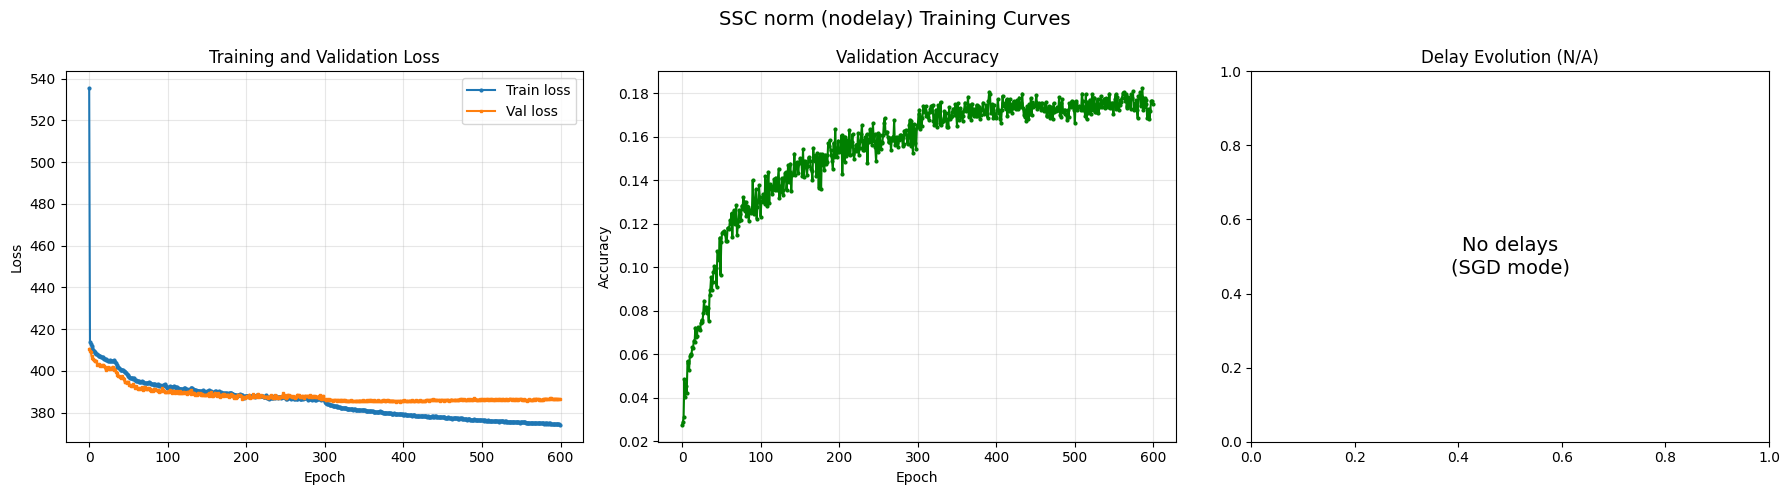

In [11]:
plot_training_curves(training_log)

## 12. Hidden-Perturbation Sweep

Apply perturbation at the 1st hidden layer output for
f in {0, 0.2, 0.4, 0.6, 0.8, 1.0}.
Each level is repeated 3 times with different random seeds to get
error bars.

**Interpretation guide:**
- If accuracy degrades with increasing f: the hidden layer preserves
  temporal codes and downstream layers depend on spike timing.
- If accuracy stays flat: the 1st hidden layer has collapsed temporal
  structure into rate codes — only spike counts matter downstream.

In [12]:
print(
    f"=== Hidden-Layer Perturbation Sweep "
    f"(SSC {DATASET_KEY}, {DELAY_TAG}) ==="
)
sweep_results = run_hidden_perturbation_sweep(
    net, test_loader, f_values=F_VALUES, num_repeats=NUM_REPEATS
)

=== Hidden-Layer Perturbation Sweep (SSC norm, nodelay) ===
  f=0.0:  accuracy = 0.1802 +/- 0.0000
  f=0.2:  accuracy = 0.0452 +/- 0.0006
  f=0.4:  accuracy = 0.0447 +/- 0.0005
  f=0.6:  accuracy = 0.0460 +/- 0.0016
  f=0.8:  accuracy = 0.0453 +/- 0.0010
  f=1.0:  accuracy = 0.0426 +/- 0.0015


## 13. Plot Results

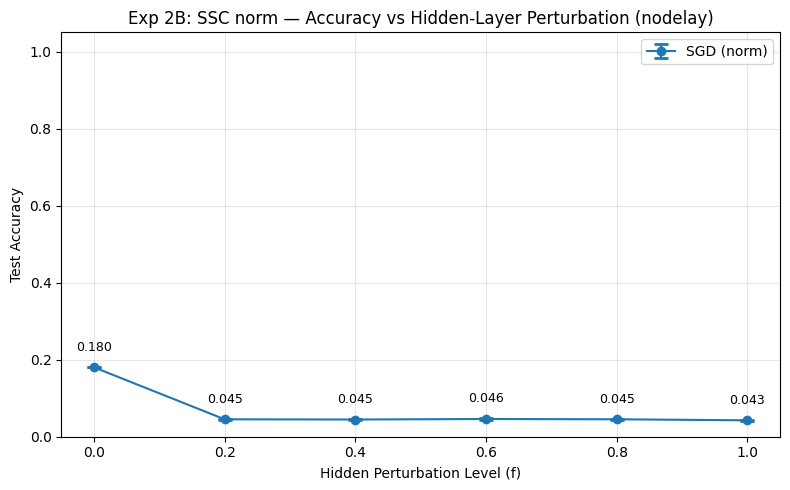

Figure saved to log/ssc_norm_nodelay_hidden_perturbation.png


In [13]:
plot_hidden_perturbation_curve(sweep_results)

## 14. Save Results

Save the sweep results and training log to JSON for later comparison
across dataset variants and delay/no-delay modes.

In [14]:
# Convert results to JSON-serialisable format
results_serialisable = {
    str(f_val): {
        "mean":   float(data["mean"]),
        "std":    float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

os.makedirs("log", exist_ok=True)
results_path = (
    f"log/ssc_{DATASET_KEY}_{DELAY_TAG}_hidden_perturbation_results.json"
)
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Results saved to {results_path}")

# Save training log
log_path = f"log/ssc_{DATASET_KEY}_{DELAY_TAG}_training_log.json"
training_log_serialisable = {
    k: [float(v) for v in vals] if isinstance(vals, list) else vals
    for k, vals in training_log.items()
}
with open(log_path, "w") as fp:
    json.dump(training_log_serialisable, fp, indent=2)
print(f"Training log saved to {log_path}")

Results saved to log/ssc_norm_nodelay_hidden_perturbation_results.json
Training log saved to log/ssc_norm_nodelay_training_log.json


## 15. Model Analysis

Print delay statistics and weight statistics for inspection.

In [15]:
print(
    f"=== Learned Parameter Analysis "
    f"(SSC {DATASET_KEY}, {DELAY_TAG}) ==="
)

# Delay statistics
delays = net.get_delays()
if delays:
    for delay_name, delay_values in delays.items():
        if len(delay_values) > 0:
            print(
                f"Learned {delay_name}: "
                f"mean={np.mean(delay_values):.2f}, "
                f"std={np.std(delay_values):.2f}, "
                f"min={np.min(delay_values):.2f}, "
                f"max={np.max(delay_values):.2f}"
            )
else:
    print("No delays (SGD mode)")

# Weight statistics per layer
for name, param in net.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"{name}: mean={w.mean().item():.4f}, "
            f"std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

=== Learned Parameter Analysis (SSC norm, nodelay) ===
No delays (SGD mode)
fc1.weight_g: mean=64.0984, std=66.9133, shape=[128, 1, 1, 1, 1]
fc1.weight_v: mean=1.7026, std=21.4432, shape=[128, 285, 1, 1, 1]
fc2.weight_g: mean=65.4961, std=78.0370, shape=[128, 1, 1, 1, 1]
fc2.weight_v: mean=0.5404, std=17.6260, shape=[128, 128, 1, 1, 1]
fc3.weight_g: mean=89.4868, std=35.5416, shape=[35, 1, 1, 1, 1]
fc3.weight_v: mean=-2.5422, std=19.6604, shape=[35, 128, 1, 1, 1]
